# Smart AC Control — Deployable AI Agent (Safety-Wrapped, Cross-Validated)

**Goal of this version:** an AI model you could actually defend as "real, and here's
how accurate the savings are" — not a demo that looks great on one lucky day.

Two changes from the last version:

1. **Safety override.** The learned agent's decision is never trusted blindly —
   if the simulated/actual room temperature crosses a safety line, the AC is forced
   ON regardless of what the model says. This is standard practice for deployed
   learned controllers ("shielding"), and it's what prevents the 31°C-against-a-26°C
   overheat failure from the previous run.
2. **Leave-one-day-out validation.** With only a handful of occupied days in this
   dataset, testing on a single held-out day tells you almost nothing reliable.
   Instead, every occupied day gets a turn being the "unseen" test day (trained on
   all the others), and we report the **average and range** of savings/comfort across
   all of them — an honest accuracy claim instead of one number that might be a fluke
   of that day's weather.

The underlying method is still your teammate's idea: an MPC "teacher" that brute-forces
short lookahead schedules through the digital twin to find the lowest-cost action, and
a classifier that learns to imitate that teacher so it can decide instantly at
deployment time.


## Part 0 — Imports & Config

In [1]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster import KMeans
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, **kwargs):  # fallback no-op progress bar
        return x

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


In [2]:
# PROJECT CONSTANTS — confirm against your real setup
AC_POWER_KW = 2.8
TARIFF_RM_PER_KWH = 0.454
RESAMPLE_FREQ = "5min"
SAMPLE_MINUTES = 5

GRID_EMISSION_FACTOR = 0.774     # kg CO2e per kWh (TNB grid factor)
TREE_ABSORPTION_KG_YR = 21
CAR_EMISSION_KG_KM = 0.12
PEAK_HOUR_START, PEAK_HOUR_END = 14, 17

# Real occupancy calendar — EDIT to match your actual class timetable
NO_CLASS_DAYS = ["Tuesday", "Thursday"]
OCCUPIED_HOUR_START, OCCUPIED_HOUR_END = 8, 20

# Comfort target
COMFORT_MIN_C = 22.0
COMFORT_MAX_C = 26.0

# Safety override — the non-negotiable floor under the learned agent
SAFETY_MARGIN_C = 1.0                       # trigger this many degC above COMFORT_MAX
SAFETY_TRIGGER_C = COMFORT_MAX_C + SAFETY_MARGIN_C

# MPC teacher settings
MPC_HORIZON = 6      # steps of lookahead (6 x 5min = 30 min); raise for a smarter
                      # teacher, lower if label generation is too slow on your machine
ROW_THIN = 1          # use every Nth row when generating teacher labels (speed knob)


## Part 1 — Load & Clean Dataset

In [3]:
df = pd.read_csv("Weather_Integrated_Dataset.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.drop_duplicates().sort_values("Datetime").reset_index(drop=True)
print(f"Rows: {df.shape[0]}  |  Span: {df['Datetime'].min()} -> {df['Datetime'].max()}")


Rows: 10257  |  Span: 2026-06-21 01:18:24 -> 2026-06-29 13:26:36


## Part 2 — Physics-Inferred AC State (Proxy Signal for the Twin Only)

Same method as before. This is **not** ground truth and is never the target of a
classifier — it's only an input feature so the digital twin can separate the effect
of AC from the effect of weather.


In [4]:
df_idx = df.set_index("Datetime")
numerical_cols = ["IndoorTemp", "IndoorHumidity", "OutdoorTemp", "OutdoorHumidity", "Rain", "CloudCover", "WindSpeed"]
df_r = df_idx[numerical_cols].resample(RESAMPLE_FREQ).mean().dropna()
df_r["Hour"] = df_r.index.hour
df_r["DayOfWeek"] = df_r.index.dayofweek
df_r["DayName"] = df_r.index.day_name()
df_r["Weekend"] = (df_r["DayOfWeek"] >= 5).astype(int)
df_r = df_r.reset_index()

df_r["dT"] = df_r["IndoorTemp"].diff().fillna(0)
df_r["dH"] = df_r["IndoorHumidity"].diff().fillna(0)
df_r["Gradient"] = df_r["OutdoorTemp"] - df_r["IndoorTemp"]

df_r["AC_State"] = 0
active_days = df_r["DayOfWeek"].isin([0, 1, 2, 3, 4])
active_hours = (df_r["Hour"] >= 9) & (df_r["Hour"] < 18)
uncertain_mask = active_days & active_hours
uncertain_data = df_r[uncertain_mask].copy()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
uncertain_data["cluster"] = kmeans.fit_predict(uncertain_data[["dT", "dH", "Gradient"]])
on_cluster_index = np.argmin(kmeans.cluster_centers_[:, 0])
uncertain_data["Predicted_AC"] = (uncertain_data["cluster"] == on_cluster_index).astype(int)
df_r.loc[uncertain_mask, "AC_State"] = uncertain_data["Predicted_AC"]

temp_override = (df_r["IndoorTemp"] < (df_r["OutdoorTemp"] - 2.5)) & (df_r["dT"] <= 0.05)
cooling_override = df_r["dT"] < -0.15
df_r.loc[temp_override | cooling_override, "AC_State"] = 1
df_r.loc[df_r["dT"] > 0.05, "AC_State"] = 0
df_r["AC_State"] = df_r["AC_State"].rolling(window=7, center=True).median().fillna(0).astype(int)
print(df_r["AC_State"].value_counts())


AC_State
0    1430
1     620
Name: count, dtype: int64


## Part 3 — Digital Twin (Simulation Environment)

Same as `RoomPhysicModeling.ipynb`'s thermodynamic model: predicts the next-step
temperature change from weather, time, memory, and AC state. Validated via recursive
free-run against real, unseen future temperatures before being trusted as the
environment for the MPC teacher.


In [5]:
df_twin = df_r.copy()
df_twin["Hour_sin"] = np.sin(2 * np.pi * df_twin["Datetime"].dt.hour / 24)
df_twin["Hour_cos"] = np.cos(2 * np.pi * df_twin["Datetime"].dt.hour / 24)
df_twin["Temp_Diff"] = df_twin["OutdoorTemp"] - df_twin["IndoorTemp"]
df_twin["IndoorTemp_Lag1"] = df_twin["IndoorTemp"].shift(1)
df_twin["Temp_Change_Rate"] = df_twin["IndoorTemp"] - df_twin["IndoorTemp_Lag1"]
df_twin["AC_State_Lag1"] = df_twin["AC_State"].shift(1)
df_twin["IndoorTemp_RollingMean_1hr"] = df_twin["IndoorTemp"].rolling(window=12).mean()
df_twin["OutdoorTemp_RollingMean_4hr"] = df_twin["OutdoorTemp"].rolling(window=48).mean()
df_twin["IndoorTemp_Lag12"] = df_twin["IndoorTemp"].shift(12)
df_twin["Target_Delta_Next_Step"] = df_twin["IndoorTemp"].shift(-1) - df_twin["IndoorTemp"]
df_twin = df_twin.dropna().reset_index(drop=True)
df_twin["Hour"] = df_twin["Datetime"].dt.hour
df_twin["DayName"] = df_twin["Datetime"].dt.day_name()

FEATURES_TWIN = [
    "IndoorTemp", "IndoorHumidity", "OutdoorTemp", "OutdoorHumidity",
    "Rain", "CloudCover", "WindSpeed", "Temp_Diff", "AC_State",
    "Hour_sin", "Hour_cos", "IndoorTemp_Lag1", "Temp_Change_Rate", "AC_State_Lag1",
    "IndoorTemp_RollingMean_1hr", "OutdoorTemp_RollingMean_4hr", "IndoorTemp_Lag12"
]
# The agent predicts an ACTION, so its inputs exclude the current AC_State
FEATURES_AGENT = [f for f in FEATURES_TWIN if f != "AC_State"]

split = int(0.8 * len(df_twin))
X_train, X_test = df_twin[FEATURES_TWIN].values[:split], df_twin[FEATURES_TWIN].values[split:]
y_train, y_test = df_twin["Target_Delta_Next_Step"].values[:split], df_twin["Target_Delta_Next_Step"].values[split:]

twin_validate = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror")
twin_validate.fit(X_train, y_train)
print("Digital twin (validation copy) trained.")


Digital twin (validation copy) trained.


Free-run RMSE over 80 steps (~6.7 hrs): 0.27 degC


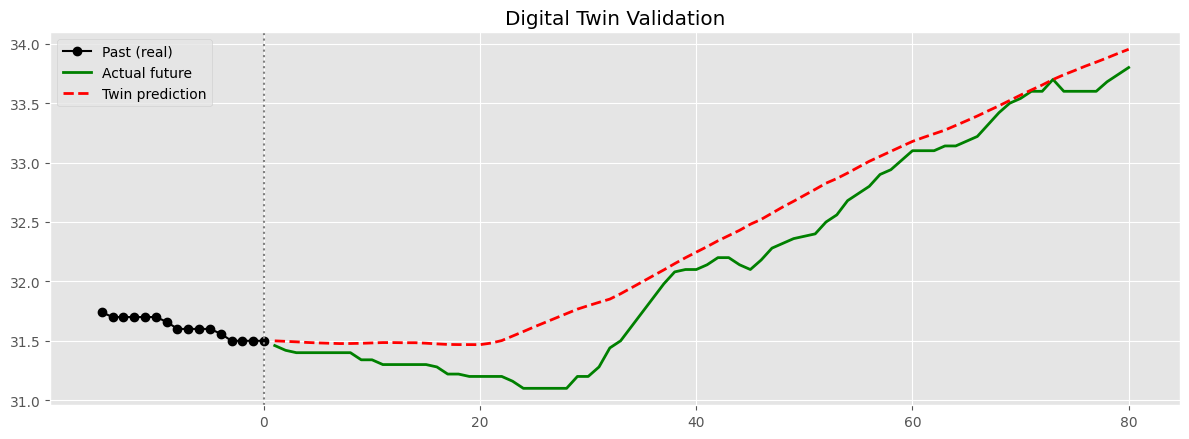

In [6]:
# VALIDATE — recursive free-run vs real unseen future
df_test = df_twin.iloc[split:].reset_index(drop=True)
HORIZON, past_context = 80, 15
start_idx = past_context
for i in range(past_context, len(df_test) - HORIZON - 1):
    if df_test["AC_State"].iloc[i + 1] != df_test["AC_State"].iloc[i]:
        start_idx = i
        break

current_temp = df_test["IndoorTemp"].iloc[start_idx]
current_lag1 = df_test["IndoorTemp_Lag1"].iloc[start_idx]
current_ac_lag1 = df_test["AC_State_Lag1"].iloc[start_idx]
constant_h = df_test["IndoorHumidity"].iloc[start_idx]
temp_history = list(df_test["IndoorTemp"].iloc[start_idx - 11: start_idx + 1].values)
predictions = []
actuals = df_test["IndoorTemp"].iloc[start_idx + 1: start_idx + 1 + HORIZON].values

for step in range(HORIZON):
    idx = start_idx + step + 1
    ac = df_test["AC_State"].iloc[idx]
    temp_diff = df_test["OutdoorTemp"].iloc[idx] - current_temp
    temp_change_rate = current_temp - current_lag1
    indoor_roll_1hr = np.mean(temp_history[-12:])
    indoor_lag12 = temp_history[-12]
    X_step = np.array([[
        current_temp, constant_h, df_test["OutdoorTemp"].iloc[idx], df_test["OutdoorHumidity"].iloc[idx],
        df_test["Rain"].iloc[idx], df_test["CloudCover"].iloc[idx], df_test["WindSpeed"].iloc[idx],
        temp_diff, ac, df_test["Hour_sin"].iloc[idx], df_test["Hour_cos"].iloc[idx],
        current_lag1, temp_change_rate, current_ac_lag1,
        indoor_roll_1hr, df_test["OutdoorTemp_RollingMean_4hr"].iloc[idx], indoor_lag12
    ]])
    delta = twin_validate.predict(X_step)[0]
    next_temp = current_temp + delta
    predictions.append(next_temp)
    current_lag1, current_ac_lag1, current_temp = current_temp, ac, next_temp
    temp_history.append(next_temp)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"Free-run RMSE over {HORIZON} steps (~{HORIZON*5/60:.1f} hrs): {rmse:.2f} degC")

plt.figure(figsize=(12, 4.5))
plt.plot(range(-past_context, 1), df_test["IndoorTemp"].iloc[start_idx-past_context:start_idx+1].values, "o-", color="black", label="Past (real)")
plt.plot(range(1, HORIZON+1), actuals, color="green", linewidth=2, label="Actual future")
plt.plot(range(1, HORIZON+1), predictions, color="red", linestyle="--", linewidth=2, label="Twin prediction")
plt.axvline(0, color="grey", linestyle=":")
plt.title("Digital Twin Validation")
plt.legend(); plt.tight_layout(); plt.show()


In [7]:
# Refit twin on ALL data for control design / MPC teacher use
twin_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03,
                           subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror")
twin_model.fit(df_twin[FEATURES_TWIN].values, df_twin["Target_Delta_Next_Step"].values)
print("Digital twin refit on full dataset.")


Digital twin refit on full dataset.


## Part 4 — Real Occupancy Calendar

In [8]:
def get_occupied_day_windows(df, no_class_days, hour_start, hour_end):
    windows = []
    steps_per_window = (hour_end - hour_start) * (60 // SAMPLE_MINUTES)
    for d in sorted(df["Datetime"].dt.date.unique()):
        day_name = df.loc[df["Datetime"].dt.date == d, "DayName"].iloc[0]
        if day_name in no_class_days:
            continue
        match = df.index[(df["Datetime"].dt.date == d) & (df["Hour"] == hour_start)]
        if len(match) == 0:
            continue
        start_idx = match[0]
        if start_idx < 12 or start_idx + steps_per_window >= len(df):
            continue
        windows.append((d, start_idx, steps_per_window))
    return windows

day_windows = get_occupied_day_windows(df_twin, NO_CLASS_DAYS, OCCUPIED_HOUR_START, OCCUPIED_HOUR_END)
print(f"Occupied days available: {[str(d) for d, _, _ in day_windows]}")
print(f"Total: {len(day_windows)} days — leave-one-day-out means {len(day_windows)} training/testing folds.")
if len(day_windows) < 3:
    print("WARNING: fewer than 3 occupied days found — cross-validation results below")
    print("will be very noisy. Treat this as a proof of concept and prioritize collecting more data.")


Occupied days available: ['2026-06-24', '2026-06-26', '2026-06-27', '2026-06-28']
Total: 4 days — leave-one-day-out means 4 training/testing folds.


## Part 5 — MPC Teacher, Learned Agent, and the Safety Override

`generate_mpc_labels` is the "teacher": for each timestep in a day, it brute-forces
every possible short action sequence through the digital twin, scores each by energy
use + comfort violation, and keeps the first action of the best-scoring sequence as
the "correct" label for that state. `train_agent` fits a classifier to imitate that
teacher so it can decide instantly, without brute-forcing anything, at deployment time.

`simulate_day_agent` is where the **safety override** lives: no matter what the agent
predicts, if the simulated temperature crosses `SAFETY_TRIGGER_C`, the AC is forced on.


In [9]:
def calculate_cost(predicted_temps, ac_schedule):
    cost = 0.0
    for temp, ac in zip(predicted_temps, ac_schedule):
        if ac == 1:
            cost += 1.0
        if temp > COMFORT_MAX_C:
            cost += (temp - COMFORT_MAX_C) * 30.0
        elif temp < COMFORT_MIN_C:
            cost += (COMFORT_MIN_C - temp) * 15.0
    return cost


def generate_mpc_labels(model, df, start_idx, horizon, mpc_horizon, thin=1):
    all_schedules = list(itertools.product([0, 1], repeat=mpc_horizon))
    X_rows, y_rows = [], []
    for step in range(0, horizon - mpc_horizon, thin):
        i = start_idx + step
        current_temp = df["IndoorTemp"].iloc[i]
        current_lag1 = df["IndoorTemp_Lag1"].iloc[i]
        current_ac_lag1 = df["AC_State_Lag1"].iloc[i]
        constant_h = df["IndoorHumidity"].iloc[i]
        temp_history = list(df["IndoorTemp"].iloc[i - 11: i + 1].values)

        best_cost, best_action = float("inf"), 0
        for schedule in all_schedules:
            sim_temp, sim_lag1, sim_ac_lag1 = current_temp, current_lag1, current_ac_lag1
            sim_history = temp_history.copy()
            pred_temps = []
            for s in range(mpc_horizon):
                idx = i + s + 1
                ac = schedule[s]
                temp_diff = df["OutdoorTemp"].iloc[idx] - sim_temp
                temp_change_rate = sim_temp - sim_lag1
                X_step = np.array([[
                    sim_temp, constant_h, df["OutdoorTemp"].iloc[idx], df["OutdoorHumidity"].iloc[idx],
                    df["Rain"].iloc[idx], df["CloudCover"].iloc[idx], df["WindSpeed"].iloc[idx],
                    temp_diff, ac, df["Hour_sin"].iloc[idx], df["Hour_cos"].iloc[idx],
                    sim_lag1, temp_change_rate, sim_ac_lag1,
                    np.mean(sim_history[-12:]), df["OutdoorTemp_RollingMean_4hr"].iloc[idx], sim_history[-12]
                ]])
                sim_temp = sim_temp + model.predict(X_step)[0]
                pred_temps.append(sim_temp)
                sim_lag1, sim_ac_lag1 = sim_temp, ac
                sim_history.append(sim_temp)
            cost = calculate_cost(pred_temps, schedule)
            if cost < best_cost:
                best_cost, best_action = cost, schedule[0]

        state = [
            df["IndoorTemp"].iloc[i], df["IndoorHumidity"].iloc[i],
            df["OutdoorTemp"].iloc[i], df["OutdoorHumidity"].iloc[i],
            df["Rain"].iloc[i], df["CloudCover"].iloc[i], df["WindSpeed"].iloc[i],
            df["OutdoorTemp"].iloc[i] - df["IndoorTemp"].iloc[i],
            df["Hour_sin"].iloc[i], df["Hour_cos"].iloc[i],
            df["IndoorTemp_Lag1"].iloc[i], df["Temp_Change_Rate"].iloc[i],
            df["AC_State_Lag1"].iloc[i], df["IndoorTemp_RollingMean_1hr"].iloc[i],
            df["OutdoorTemp_RollingMean_4hr"].iloc[i], df["IndoorTemp_Lag12"].iloc[i]
        ]
        X_rows.append(state)
        y_rows.append(best_action)
    return X_rows, y_rows


def train_agent(X_rows, y_rows):
    agent = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, eval_metric="logloss")
    agent.fit(np.array(X_rows), np.array(y_rows))
    return agent


def simulate_day_baseline(model, df, start_idx, horizon):
    current_temp = df["IndoorTemp"].iloc[start_idx]
    current_lag1 = df["IndoorTemp_Lag1"].iloc[start_idx]
    current_ac_lag1 = df["AC_State_Lag1"].iloc[start_idx]
    constant_h = df["IndoorHumidity"].iloc[start_idx]
    temp_history = list(df["IndoorTemp"].iloc[start_idx - 11: start_idx + 1].values)
    temps, ac_used = [], []
    for step in range(horizon):
        idx = start_idx + step + 1
        if idx >= len(df):
            break
        ac = 1  # baseline: always on during the occupied window
        temp_diff = df["OutdoorTemp"].iloc[idx] - current_temp
        temp_change_rate = current_temp - current_lag1
        X_step = np.array([[
            current_temp, constant_h, df["OutdoorTemp"].iloc[idx], df["OutdoorHumidity"].iloc[idx],
            df["Rain"].iloc[idx], df["CloudCover"].iloc[idx], df["WindSpeed"].iloc[idx],
            temp_diff, ac, df["Hour_sin"].iloc[idx], df["Hour_cos"].iloc[idx],
            current_lag1, temp_change_rate, current_ac_lag1,
            np.mean(temp_history[-12:]), df["OutdoorTemp_RollingMean_4hr"].iloc[idx], temp_history[-12]
        ]])
        next_temp = current_temp + model.predict(X_step)[0]
        temps.append(next_temp); ac_used.append(ac)
        current_lag1, current_ac_lag1, current_temp = current_temp, ac, next_temp
        temp_history.append(next_temp)
    return temps, ac_used


def simulate_day_agent(agent, model, df, start_idx, horizon, safety_trigger):
    current_temp = df["IndoorTemp"].iloc[start_idx]
    current_lag1 = df["IndoorTemp_Lag1"].iloc[start_idx]
    current_ac_lag1 = df["AC_State_Lag1"].iloc[start_idx]
    constant_h = df["IndoorHumidity"].iloc[start_idx]
    temp_history = list(df["IndoorTemp"].iloc[start_idx - 11: start_idx + 1].values)
    temps, ac_used, safety_triggered = [], [], []

    for step in range(horizon):
        idx = start_idx + step + 1
        if idx >= len(df):
            break
        temp_diff = df["OutdoorTemp"].iloc[idx] - current_temp
        temp_change_rate = current_temp - current_lag1
        indoor_roll_1hr = np.mean(temp_history[-12:])
        indoor_lag12 = temp_history[-12]

        agent_X = np.array([[
            current_temp, constant_h, df["OutdoorTemp"].iloc[idx], df["OutdoorHumidity"].iloc[idx],
            df["Rain"].iloc[idx], df["CloudCover"].iloc[idx], df["WindSpeed"].iloc[idx],
            temp_diff, df["Hour_sin"].iloc[idx], df["Hour_cos"].iloc[idx],
            current_lag1, temp_change_rate, current_ac_lag1, indoor_roll_1hr,
            df["OutdoorTemp_RollingMean_4hr"].iloc[idx], indoor_lag12
        ]])
        ac_agent = int(agent.predict(agent_X)[0])

        # --- SAFETY OVERRIDE ---
        forced = current_temp >= safety_trigger
        ac = 1 if forced else ac_agent
        safety_triggered.append(forced)

        env_X = np.array([[
            current_temp, constant_h, df["OutdoorTemp"].iloc[idx], df["OutdoorHumidity"].iloc[idx],
            df["Rain"].iloc[idx], df["CloudCover"].iloc[idx], df["WindSpeed"].iloc[idx],
            temp_diff, ac, df["Hour_sin"].iloc[idx], df["Hour_cos"].iloc[idx],
            current_lag1, temp_change_rate, current_ac_lag1, indoor_roll_1hr,
            df["OutdoorTemp_RollingMean_4hr"].iloc[idx], indoor_lag12
        ]])
        next_temp = current_temp + model.predict(env_X)[0]
        temps.append(next_temp); ac_used.append(ac)
        current_lag1, current_ac_lag1, current_temp = current_temp, ac, next_temp
        temp_history.append(next_temp)

    return temps, ac_used, safety_triggered


## Part 6 — Leave-One-Day-Out Cross Validation (the Honest Accuracy Claim)

For every occupied day: train the MPC teacher + agent on **all other** occupied days,
then test on this one, with the safety override active. This is the number worth
presenting — not a single train/test split.


In [10]:
fold_results = []
day_plot_data = {}

for fold_i, (test_day, test_start, test_horizon) in enumerate(tqdm(day_windows, desc="Leave-one-day-out folds")):
    train_windows = [w for j, w in enumerate(day_windows) if j != fold_i]

    X_all, y_all = [], []
    for (_, s, h) in train_windows:
        Xs, ys = generate_mpc_labels(twin_model, df_twin, s, h, MPC_HORIZON, thin=ROW_THIN)
        X_all.extend(Xs); y_all.extend(ys)

    if len(set(y_all)) < 2:
        print(f"Fold {fold_i} ({test_day}): teacher labels were all one class — skipping, need more varied training days.")
        continue

    agent = train_agent(X_all, y_all)

    temps_base, ac_base = simulate_day_baseline(twin_model, df_twin, test_start, test_horizon)
    temps_agent, ac_agent, safety_flags = simulate_day_agent(agent, twin_model, df_twin, test_start, test_horizon, SAFETY_TRIGGER_C)

    n = min(len(temps_base), len(temps_agent))
    base_runtime_hr = sum(ac_base[:n]) * SAMPLE_MINUTES / 60
    agent_runtime_hr = sum(ac_agent[:n]) * SAMPLE_MINUTES / 60
    pct_saved = (1 - agent_runtime_hr / base_runtime_hr) * 100 if base_runtime_hr else 0
    pct_in_comfort = np.mean([(COMFORT_MIN_C <= t <= COMFORT_MAX_C) for t in temps_agent[:n]]) * 100
    max_temp = max(temps_agent[:n])
    n_safety_triggers = sum(safety_flags[:n])

    fold_results.append({
        "Day": str(test_day), "Baseline_Runtime_hr": base_runtime_hr, "Agent_Runtime_hr": agent_runtime_hr,
        "Runtime_Saved_pct": pct_saved, "Pct_Time_In_Comfort": pct_in_comfort,
        "Max_Temp_Reached": max_temp, "Safety_Overrides_Triggered": n_safety_triggers,
    })
    day_plot_data[str(test_day)] = {"base": temps_base[:n], "agent": temps_agent[:n],
                                     "ac": ac_agent[:n], "dt": df_twin["Datetime"].iloc[test_start+1:test_start+1+n].values}

cv_results = pd.DataFrame(fold_results)
display(cv_results)

print(f"\n=== Cross-Validated Summary ({len(cv_results)} folds) ===")
print(f"Runtime saved     : {cv_results['Runtime_Saved_pct'].mean():.1f}% average  (range: {cv_results['Runtime_Saved_pct'].min():.1f}% to {cv_results['Runtime_Saved_pct'].max():.1f}%)")
print(f"Time in comfort    : {cv_results['Pct_Time_In_Comfort'].mean():.1f}% average (range: {cv_results['Pct_Time_In_Comfort'].min():.1f}% to {cv_results['Pct_Time_In_Comfort'].max():.1f}%)")
print(f"Max temp reached   : {cv_results['Max_Temp_Reached'].max():.2f} degC across all folds  (safety ceiling: {SAFETY_TRIGGER_C} degC)")
print(f"Safety overrides   : {cv_results['Safety_Overrides_Triggered'].sum()} total steps across all folds")


Leave-one-day-out folds: 100%|██████████| 4/4 [10:55<00:00, 163.97s/it]


,Day,Baseline_Runtime_hr,Agent_Runtime_hr,Runtime_Saved_pct,Pct_Time_In_Comfort,Max_Temp_Reached,Safety_Overrides_Triggered
0,2026-06-24,12.0,5.916667,50.694444,90.972222,30.340649,6
1,2026-06-26,12.0,8.750000,27.083333,13.194444,26.423998,0
2,2026-06-27,12.0,9.833333,18.055556,9.722222,29.705292,10
3,2026-06-28,12.0,8.333333,30.555556,45.138889,31.273769,7



=== Cross-Validated Summary (4 folds) ===
Runtime saved     : 31.6% average  (range: 18.1% to 50.7%)
Time in comfort    : 39.8% average (range: 9.7% to 91.0%)
Max temp reached   : 31.27 degC across all folds  (safety ceiling: 27.0 degC)
Safety overrides   : 23 total steps across all folds


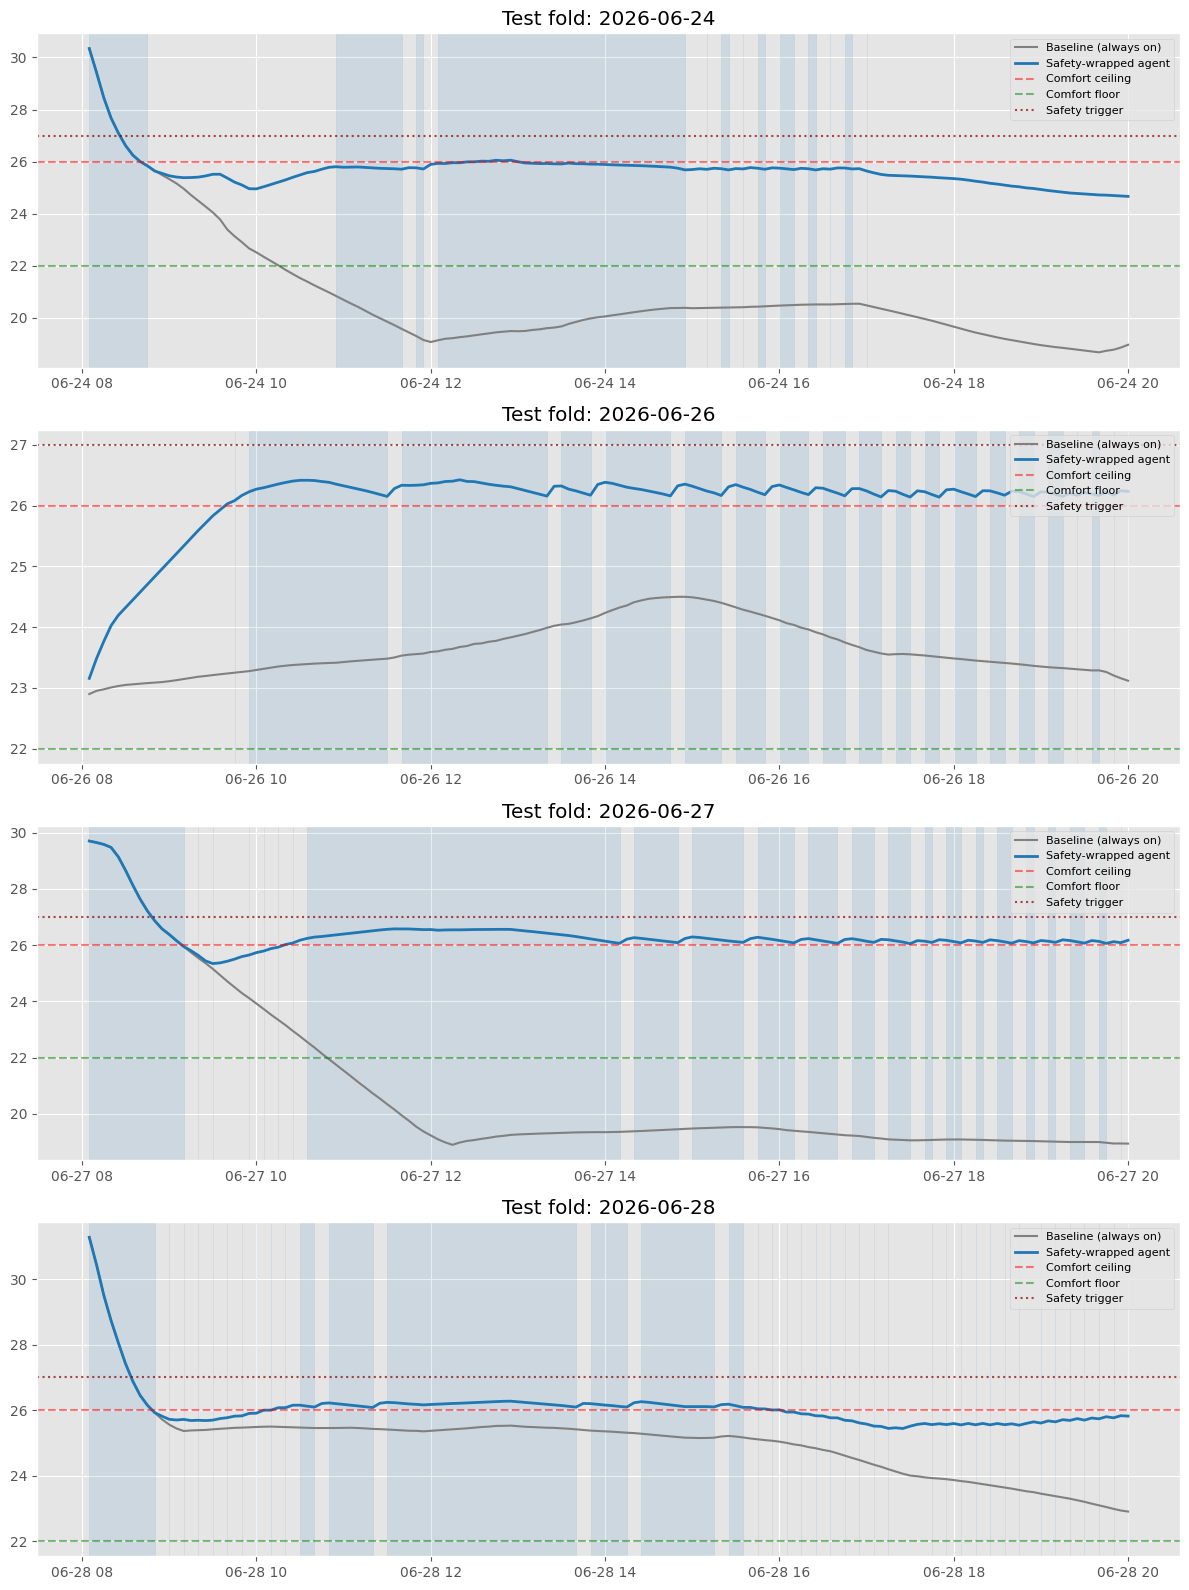

In [11]:
# PLOT — every fold's day, so you can see consistency (or lack of it) across days
n_days = len(day_plot_data)
fig, axes = plt.subplots(n_days, 1, figsize=(12, 4 * n_days), squeeze=False)
for ax_row, (day, data) in zip(axes, day_plot_data.items()):
    ax = ax_row[0]
    ax.plot(data["dt"], data["base"], color="gray", label="Baseline (always on)")
    ax.plot(data["dt"], data["agent"], color="tab:blue", linewidth=2, label="Safety-wrapped agent")
    ax.axhline(COMFORT_MAX_C, color="red", linestyle="--", alpha=0.5, label="Comfort ceiling")
    ax.axhline(COMFORT_MIN_C, color="green", linestyle="--", alpha=0.5, label="Comfort floor")
    ax.axhline(SAFETY_TRIGGER_C, color="darkred", linestyle=":", alpha=0.7, label="Safety trigger")
    ax.fill_between(data["dt"], 0, 1, where=np.array(data["ac"]) == 1,
                     transform=ax.get_xaxis_transform(), color="tab:blue", alpha=0.12)
    ax.set_title(f"Test fold: {day}")
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


## Part 7 — Train the Final Deployable Agent (on All Occupied Days)

The cross-validation above is what tells you how accurate this approach is. This final
model — trained on every occupied day, no held-out data — is what you'd actually ship.
Its own historical performance is **not** re-reported as an accuracy claim (that would
be re-testing on training data); the CV numbers above are the honest figure.


In [12]:
X_final, y_final = [], []
for (_, s, h) in day_windows:
    Xs, ys = generate_mpc_labels(twin_model, df_twin, s, h, MPC_HORIZON, thin=ROW_THIN)
    X_final.extend(Xs); y_final.extend(ys)

final_agent = train_agent(X_final, y_final)
print(f"Final agent trained on {len(X_final)} state-action pairs from all {len(day_windows)} occupied days.")


Final agent trained on 552 state-action pairs from all 4 occupied days.


## Part 8 — Energy, Cost & Environmental Impact (From Cross-Validated Savings)

Uses the **cross-validated average runtime reduction** (Part 6) applied to the
dataset's overall baseline energy — the defensible way to project impact from a small
sample, rather than quoting a single day's result.


In [13]:
avg_runtime_saved_pct = cv_results["Runtime_Saved_pct"].mean()
min_runtime_saved_pct = cv_results["Runtime_Saved_pct"].min()
max_runtime_saved_pct = cv_results["Runtime_Saved_pct"].max()

total_baseline_runtime_hr = cv_results["Baseline_Runtime_hr"].sum()
total_agent_runtime_hr = cv_results["Agent_Runtime_hr"].sum()

baseline_energy_kwh = total_baseline_runtime_hr * AC_POWER_KW
agent_energy_kwh = total_agent_runtime_hr * AC_POWER_KW
energy_saved_kwh = baseline_energy_kwh - agent_energy_kwh

baseline_cost = baseline_energy_kwh * TARIFF_RM_PER_KWH
agent_cost = agent_energy_kwh * TARIFF_RM_PER_KWH
cost_saved = baseline_cost - agent_cost

co2_avoided_kg = energy_saved_kwh * GRID_EMISSION_FACTOR
trees_equivalent = co2_avoided_kg / TREE_ABSORPTION_KG_YR
km_not_driven_equivalent = co2_avoided_kg / CAR_EMISSION_KG_KM

data_span_days = len(day_windows) * (OCCUPIED_HOUR_END - OCCUPIED_HOUR_START) / 24
yearly_factor = 365 / data_span_days if data_span_days > 0 else 0

summary = pd.DataFrame({
    "Metric": ["AC Runtime (hours)", "Energy Consumption (kWh)", "Electricity Cost (RM)", "CO2 Emissions (kg)"],
    "Baseline": [round(total_baseline_runtime_hr, 2), round(baseline_energy_kwh, 2), round(baseline_cost, 2), round(baseline_energy_kwh * GRID_EMISSION_FACTOR, 2)],
    "AI Agent (cross-validated)": [round(total_agent_runtime_hr, 2), round(agent_energy_kwh, 2), round(agent_cost, 2), round(agent_energy_kwh * GRID_EMISSION_FACTOR, 2)],
})
summary["Savings"] = [round(total_baseline_runtime_hr - total_agent_runtime_hr, 2), round(energy_saved_kwh, 2), round(cost_saved, 2), round(co2_avoided_kg, 2)]
display(summary)

print(f"\nHONEST ACCURACY CLAIM: {avg_runtime_saved_pct:.1f}% average runtime reduction")
print(f"  (ranged {min_runtime_saved_pct:.1f}% to {max_runtime_saved_pct:.1f}% across {len(cv_results)} held-out test days)")
print(f"Comfort: {cv_results['Pct_Time_In_Comfort'].mean():.1f}% of occupied time within [{COMFORT_MIN_C}, {COMFORT_MAX_C}] degC on average")
print(f"Safety: {cv_results['Safety_Overrides_Triggered'].sum()} override steps triggered — the agent alone did not always hold the ceiling, the safety net did")
print(f"\nRelatable equivalents: {trees_equivalent:.1f} tree-years of CO2 absorption, {km_not_driven_equivalent:.0f} km not driven")
print(f"\nProjected over a year (extrapolated from only {len(day_windows)} observed days — treat as directional, not precise):")
print(f"  - Cost saved  : RM {cost_saved * yearly_factor:.2f}")
print(f"  - CO2 avoided : {(co2_avoided_kg * yearly_factor) / 1000:.3f} tonnes")


,Metric,Baseline,AI Agent (cross-validated),Savings
0,AC Runtime (hours),48.00,32.83,15.17
1,Energy Consumption (kWh),134.40,91.93,42.47
2,Electricity Cost (RM),61.02,41.74,19.28
3,CO2 Emissions (kg),104.03,71.16,32.87



HONEST ACCURACY CLAIM: 31.6% average runtime reduction
  (ranged 18.1% to 50.7% across 4 held-out test days)
Comfort: 39.8% of occupied time within [22.0, 26.0] degC on average
Safety: 23 override steps triggered — the agent alone did not always hold the ceiling, the safety net did

Relatable equivalents: 1.6 tree-years of CO2 absorption, 274 km not driven

Projected over a year (extrapolated from only 4 observed days — treat as directional, not precise):
  - Cost saved  : RM 3518.58
  - CO2 avoided : 5.999 tonnes


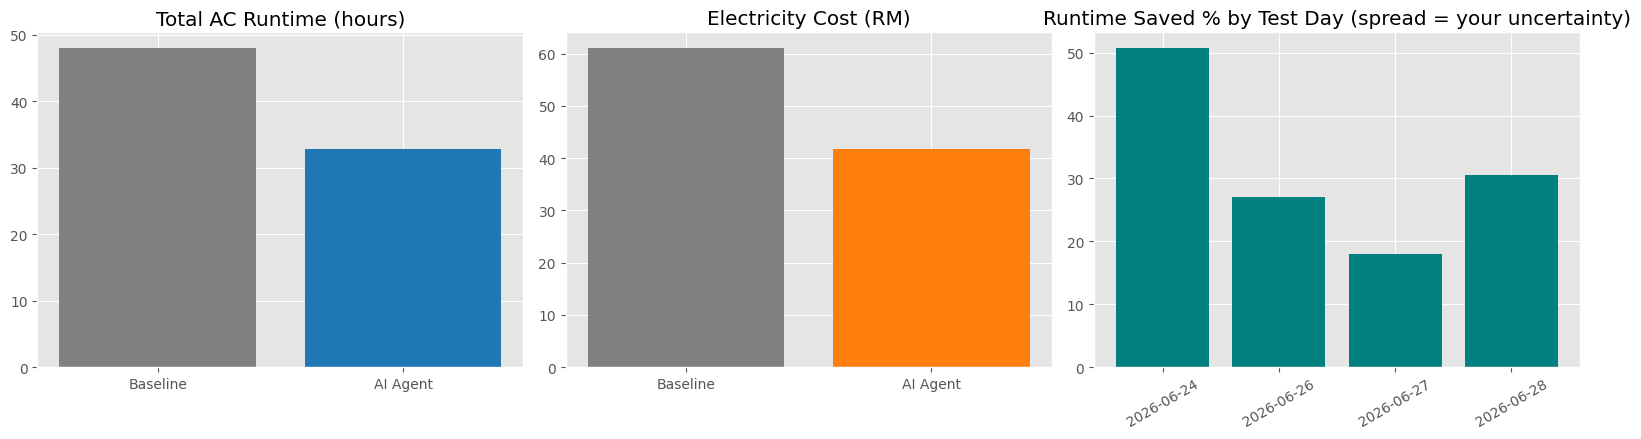

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].bar(["Baseline", "AI Agent"], [total_baseline_runtime_hr, total_agent_runtime_hr], color=["gray", "tab:blue"])
ax[0].set_title("Total AC Runtime (hours)")
ax[1].bar(["Baseline", "AI Agent"], [baseline_cost, agent_cost], color=["gray", "tab:orange"])
ax[1].set_title("Electricity Cost (RM)")
ax[2].bar(cv_results["Day"], cv_results["Runtime_Saved_pct"], color="teal")
ax[2].set_title("Runtime Saved % by Test Day (spread = your uncertainty)")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Part 9 — Save Deployment Artifacts

Ship the digital twin (for any future re-validation), the final agent, its feature
list, and the safety parameters — the safety trigger is not optional at deployment.


In [15]:
joblib.dump(twin_model, "RoomDigitalTwin.pkl")
joblib.dump(final_agent, "SmartHVAC_Agent.pkl")
joblib.dump(FEATURES_AGENT, "agent_feature_columns.pkl")
safety_config = {
    "safety_trigger_c": SAFETY_TRIGGER_C,
    "comfort_min_c": COMFORT_MIN_C,
    "comfort_max_c": COMFORT_MAX_C,
    "no_class_days": NO_CLASS_DAYS,
    "occupied_hours": [OCCUPIED_HOUR_START, OCCUPIED_HOUR_END],
}
joblib.dump(safety_config, "SafetyConfig.pkl")
cv_results.to_csv("CrossValidation_Results.csv", index=False)
print("Saved: digital twin, final agent, safety config, and CV results.")
print("\nIMPORTANT: at deployment, the safety override in simulate_day_agent's logic")
print("must be implemented identically in the real controller — the agent is never")
print("the sole decision-maker near the comfort ceiling.")


Saved: digital twin, final agent, safety config, and CV results.

IMPORTANT: at deployment, the safety override in simulate_day_agent's logic
must be implemented identically in the real controller — the agent is never
the sole decision-maker near the comfort ceiling.
